In [3]:
%pip install Seaborn

In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from pyodide.http import pyfetch

In [11]:
pd.set_option("display.max_columns", None)

<h1>I. Import Data Set:</h1>

In [13]:
async def download(url, filename):
    try:
        response = await pyfetch(url)
        if response.status == 200:
            print("Connection to URL successful")
            with open (filename, "wb") as f:
                f.write(await response.bytes())
                print(f"{filename} successfully written")
    except Exception as e :
        print("Error during download:", e)

In [14]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
filename = "laptop_prices_data.csv"

In [15]:
await download(url, filename)

Connection to URL successful
laptop_prices_data.csv successfully written


<h1>II. Dataframe</h1>

In [19]:
df = pd.read_csv(filename)
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


<h2>A. Information and Descriptive Statistics</h2>

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      238 non-null    int64  
 1   Unnamed: 0        238 non-null    int64  
 2   Manufacturer      238 non-null    object 
 3   Category          238 non-null    int64  
 4   GPU               238 non-null    int64  
 5   OS                238 non-null    int64  
 6   CPU_core          238 non-null    int64  
 7   Screen_Size_inch  238 non-null    float64
 8   CPU_frequency     238 non-null    float64
 9   RAM_GB            238 non-null    int64  
 10  Storage_GB_SSD    238 non-null    int64  
 11  Weight_pounds     238 non-null    float64
 12  Price             238 non-null    int64  
 13  Price-binned      238 non-null    object 
 14  Screen-Full_HD    238 non-null    int64  
 15  Screen-IPS_panel  238 non-null    int64  
dtypes: float64(3), int64(11), object(2)
memory u

In [23]:
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
Manufacturer        0
Category            0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    0
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_pounds       0
Price               0
Price-binned        0
Screen-Full_HD      0
Screen-IPS_panel    0
dtype: int64

In [21]:
df.describe(include = "all")

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
count,238.000000,238.000000,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238,238.000000,238.000000
unique,NaN,NaN,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Dell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160,NaN,NaN
mean,118.500000,118.500000,NaN,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,NaN,0.676471,0.323529
std,68.848868,68.848868,NaN,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,NaN,0.468809,0.468809
min,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,NaN,0.000000,0.000000
25%,59.250000,59.250000,NaN,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,NaN,0.000000,0.000000
50%,118.500000,118.500000,NaN,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,NaN,1.000000,0.000000
75%,177.750000,177.750000,NaN,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,NaN,1.000000,1.000000


<h1>III. Predictive Analytics</h1>

<h2> A. Simple Linear Regression</h2>
<p>Effect of CPU_frequency on laptop price: </p>

<h3>1. Model fit and prediction</h3>

In [30]:
X1 = df[["CPU_frequency"]]
Y1 = df["Price"]
model_1 = LinearRegression()

In [31]:
model_1.fit(X1, Y1)

LinearRegression()

In [33]:
Y1_pred = model_1.predict(X1)
Y1_pred[0:5]

array([1073.07834392, 1277.93263722, 1636.42765051, 1073.07834392,
       1175.50549057])

In [116]:
a = model_1.intercept_
b = model_1.coef_[0]
print(f"The linear equation model is: price = {a:.2f} + {b:.2f}(CPU_frequency)")

The linear equation model is: price = 253.66 + 1485.19(CPU_frequency)


<h3>2.KDE (Kernel Density Estimate) plot between actual values and prediction</h3>

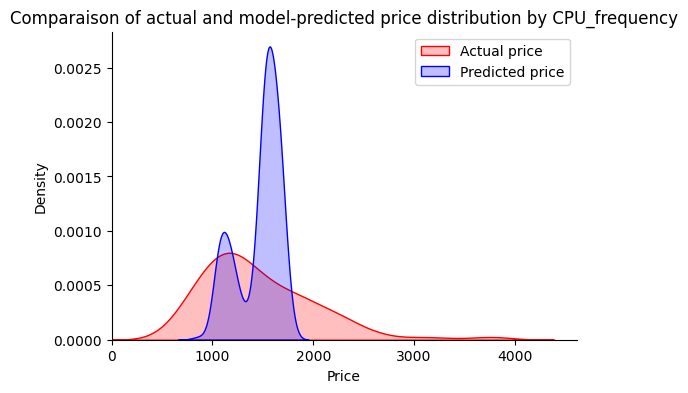

In [62]:
width =6
height = 4
plt.figure(figsize = (width, height))
sns.kdeplot(Y1, color = "red", label = "actual values", fill = True)
sns.kdeplot(Y1_pred, color = "blue", label = "predicted values", fill = True)
plt.title("Comparaison of actual and model-predicted price distribution by CPU_frequency")
sns.despine()
plt.legend(["Actual price", "Predicted price"])
plt.xlim(0,)
plt.show()

<p>The KDE comparison shows that the predicted prices are concentrated within a narrow range around the mean, whereas the actual prices exhibit substantially greater dispersion and a pronounced right tail. This suggests that the simple linear regression model using CPU frequency underfits the data, capturing only the central tendency while failing to represent the full variability and higher-price observations.</p>

<h3>3. R2, MSE, and RMSE</h3>

In [98]:
R2_1 = model_1.score(X1, Y1)
MSE_1 = mean_squared_error(Y1, Y1_pred)
RMSE_1 = root_mean_squared_error(Y1, Y1_pred)
print(f""" For the simple linear regression using CPU_frequency to predict price, the R-squared value is R2 = {R2_1:.2f},
 and the mean squared error is MSE = {MSE_1:.2f} (RMSE = {RMSE_1:.2f}).""")

 For the simple linear regression using CPU_frequency to predict price, the R-squared value is R2 = 0.13,
 and the mean squared error is MSE = 284583.44 (RMSE = 533.46).


<h3>4. Regression and residual plots</h3>

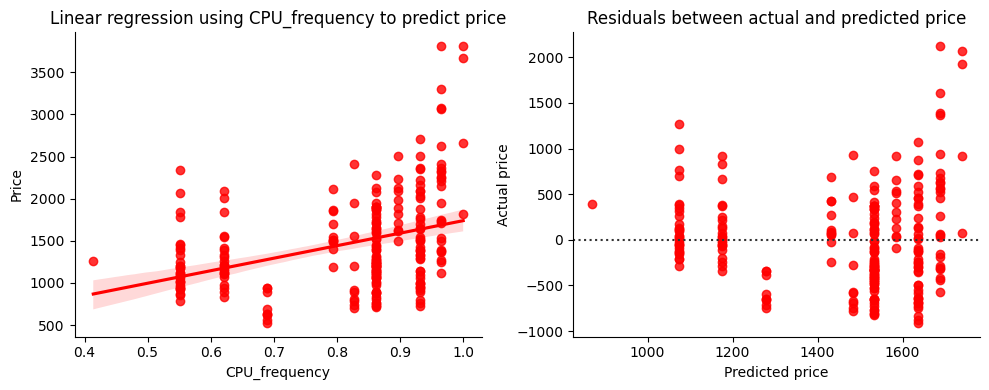

In [107]:
width = 10
height = 4

fig, axes = plt.subplots(1,2, figsize=(width, height))

sns.regplot(x = X1, y = Y1, color = "red", ax = axes[0])
axes[0].set_title("Linear regression using CPU_frequency to predict price")
sns.despine(ax = axes[0])

sns.residplot(x = Y1_pred, y = Y1, color = "red", ax = axes[1])
sns.despine(ax = axes[1])
axes[1].set_title("Residuals between actual and predicted price")
axes[1].set_xlabel("Predicted price")
axes[1].set_ylabel("Actual price")

plt.tight_layout()

<p>For the simple linear regression model using CPU frequency to predict price, the R² value of 0.13 indicates that CPU frequency explains only 13% of the variance in laptop price, suggesting weak predictive power. The MSE of 28458344 (RMSE ≈ 533.46) further indicates substantial prediction error. Together with the residual plot, these results suggest that CPU frequency alone is not sufficient to model laptop price accurately, and additional predictors should be considered.</p>

<h2>B. Multiple Linear Regression Model</h2>

<p>Effect of CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category on price.</p>

<h3>1. Model fit and prediction </h3>

In [110]:
X2 = df[["CPU_frequency", "RAM_GB", "Storage_GB_SSD", "CPU_core", "OS", "GPU", "Category"]]
Y2 = df["Price"]

In [114]:
model_2 = LinearRegression()
model_2.fit(X2, Y2)
Y2_pred = model_2.predict(X2)
Y2_pred[0:5]

array([1345.51622771,  710.44905496, 1552.37242687, 1295.00681012,
       1543.13847022])

In [119]:
a = model_2.intercept_
b = model_2.coef_
print(f"The multiple linear regression model is price = {a:.2f} + {b[0]:.2f}(CPU_frequency) + {b[1]:.2f}(RAM_GB)+ {b[2]:.2f}(Storage_GB_SSD) + {b[3]:.2f}(CPU_core)+ {b[4]:.2f}(OS) + {b[5]:.2f}(GPU) + {b[6]:.2f}(Category)")

The multiple linear regression model is price = -841.99 + 961.28(CPU_frequency) + 86.81(RAM_GB)+ 0.39(Storage_GB_SSD) + 65.66(CPU_core)+ -427.45(OS) + 97.80(GPU) + 191.30(Category)


<h3>2. KDE (Kernel Density Estimate) Plot between actual price and predicted price</h3>

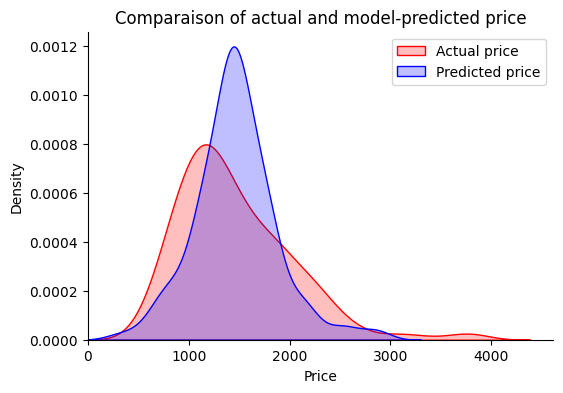

In [147]:
width = 6
height = 4
plt.figure(figsize=(width, height))
sns.kdeplot(Y2,color = "red", label = "Actual price", fill = True)
sns.kdeplot(Y2_pred, color = "blue", label = "Predicted price", fill = True)
sns.despine()
plt.xlim(0,)
plt.legend()
plt.title("Comparaison of actual and model-predicted price")

plt.show()

<h3>3. R2, MSE, and RMSE</h3>

In [141]:
R2_2 = model_2.score(X2, Y2)
MSE_2 = mean_squared_error(Y2, Y2_pred)
RMSE_2 = root_mean_squared_error(Y2, Y2_pred)
print(f"""For the multiple linear regression modelusing CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU, and Category to predict price,
R2 = {R2_2:.2f}, MSE = {MSE_2:.2f}, RMSE = {RMSE_2:.2f}""")

For the multiple linear regression modelusing CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU, and Category to predict price,
R2 = 0.51, MSE = 161680.57, RMSE = 402.10


<p>Comparing two regression models for predicting price shows that using CPU frequency alone yields a poor fit (R² = 0.13, RMSE = 533.46), explaining only a small fraction of the variance. In contrast, a multiple linear regression incorporating CPU frequency, RAM, SSD storage, CPU cores, OS, GPU, and category improves performance (R² = 0.51, RMSE = 402.10), capturing more than half of the price variability and providing more accurate predictions.</p>

<h2> C. Polynomial Regression Model</h2>

<p>Polynomial models predicting the effect of CPU_frequency on price</p>

<h3>1. Model Fit and Prediction </h3>

In [153]:
X3 = df["CPU_frequency"] #Expected 1D structure for X in polynomial models
Y3 = df["Price"]

<h4>a. 1st Degree Polynomial Model:</h4>

In [207]:
model_3_1 = np.polyfit(X3, Y3, 1) 
equation_model_degree_1 = np.poly1d(model_3_1)
Y_pred_3_1 = equation_model_degree_1(X3)
print(f"Polynomial equation degree 1: price = {equation_model_degree_1}")

Polynomial equation degree 1: price =  
1485 x + 253.7


<h4>b. 2nd Degree Polynomial Model:</h4>

In [208]:
model_3_2 = np.polyfit(X3, Y3, 2) 
equation_model_degree_2 = np.poly1d(model_3_2)
Y_pred_3_2 = equation_model_degree_2(X3)
print(f"Polynomial equation degree 2: price = {equation_model_degree_2}")

Polynomial equation degree 2: price =            2
1.191e+04 x - 1.643e+04 x + 6703


<h4>c. 3rd Degree Polynomial Model:</h4>

In [209]:
model_3_3 = np.polyfit(X3, Y3, 3) 
equation_model_degree_3 = np.poly1d(model_3_3)
Y_pred_3_3 = equation_model_degree_3(X3)
print(f"Polynomial equation degree 3: price = {equation_model_degree_3}")

Polynomial equation degree 3: price =            3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238


<h4>d. 4th Degree Polynomial Model:</h4>

In [210]:
model_3_4 = np.polyfit(X3, Y3, 4) 
equation_model_degree_4 = np.poly1d(model_3_4)
Y_pred_3_4 = equation_model_degree_4(X3)
print(f"Polynomial equation degree 4: price = {equation_model_degree_4}")

Polynomial equation degree 4: price =            4             3             2
1.552e+05 x - 4.162e+05 x + 4.134e+05 x - 1.798e+05 x + 3.008e+04


<h4>e. 5th Degree Polynomial Model:</h4>

In [211]:
model_3_5 = np.polyfit(X3, Y3, 5) 
equation_model_degree_5 = np.poly1d(model_3_5)
Y_pred_3_5 = equation_model_degree_5(X3)
print(f"Polynomial equation degree 5: price = {equation_model_degree_5}")

Polynomial equation degree 5: price =            5            4             3             2
1.357e+06 x - 4.72e+06 x + 6.458e+06 x - 4.336e+06 x + 1.425e+06 x - 1.818e+05


<h3>2. Plots: Polynomial fits and KDE </h3>

<h4> a. Polynomial fit</h4>

In [201]:
def polynomial_graph(equation_model, X, Y, X_name, Y_name, poly_degree):
    #polynomial graph:
    X_poly = np.linspace(X.min(), X.max(), 100)
    Y_poly = equation_model(X_poly)
    #Plot polynomial graph and actual data:
    plt.figure(figsize =(5,4))
    plt.plot(X, Y, ".", X_poly, Y_poly, "-")
    plt.title(f" {poly_degree} Polynomial Fit for the Effect of {X_name.upper()} on {Y_name.upper()}")
    plt.xlabel(f"{X_name}")
    plt.ylabel(f"{Y_name}")
    plt.ylim(0,)
    sns.despine()

    plt.show()
    plt.close()
    

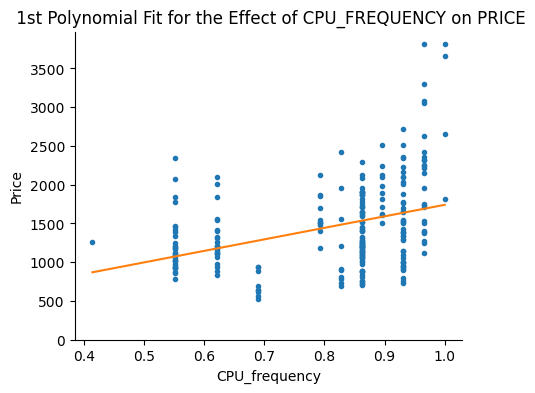

In [202]:
polynomial_graph(equation_model_degree_1, X3, Y3, "CPU_frequency", "Price", "1st")

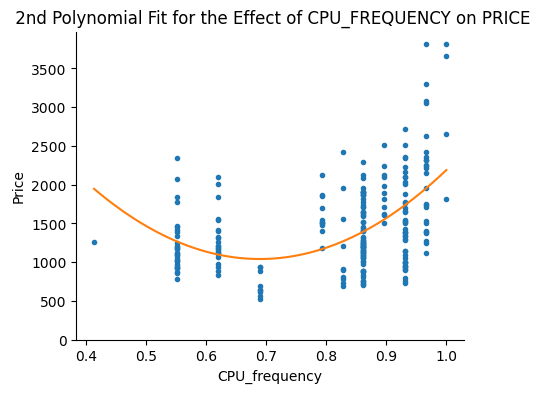

In [203]:
polynomial_graph(equation_model_degree_2, X3, Y3, "CPU_frequency", "Price", "2nd")

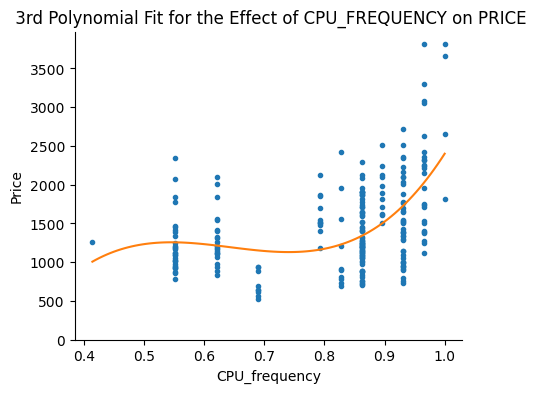

In [204]:
polynomial_graph(equation_model_degree_3, X3, Y3, "CPU_frequency", "Price", "3rd")

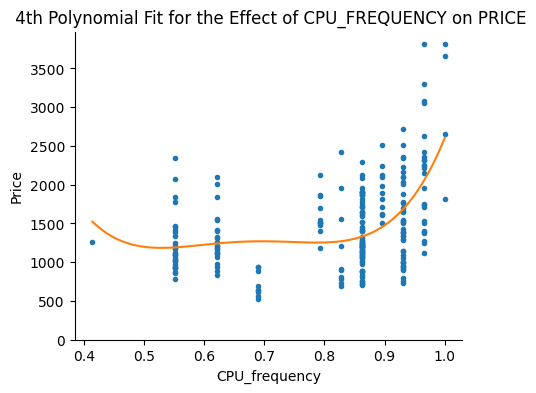

In [205]:
polynomial_graph(equation_model_degree_4, X3, Y3, "CPU_frequency", "Price", "4th")

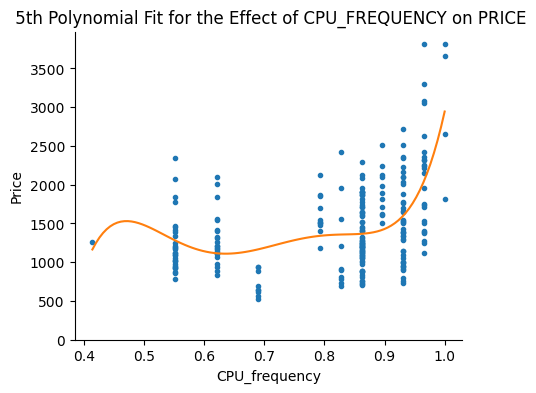

In [206]:
polynomial_graph(equation_model_degree_5, X3, Y3, "CPU_frequency", "Price", "5th")

<h3>b. KDE (Kernel Density Estimate) Plot between actual price and predicted price for polynomial models:</h3>

In [221]:
def KDE_plot(Y, Y_pred, polyDegree):
    plt.figure(figsize=(6,4))
    sns.kdeplot(Y, label = "Actual Price", color = "red", fill = True)
    sns.kdeplot(Y_pred, label = "Predicted price", color = "blue", fill = True)
    sns.despine()
    plt.legend()
    plt.xlim(0,)
    plt.title(f"KDE plot comparing actual price and {polyDegree} dgree polynomial model-predicted price")

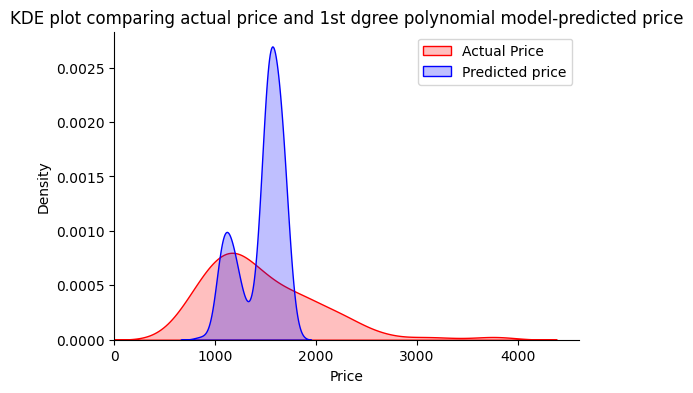

In [222]:
KDE_plot(Y3, Y_pred_3_1, "1st")

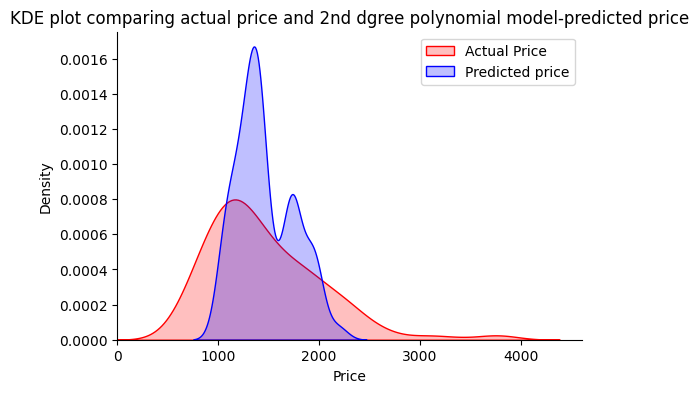

In [223]:
KDE_plot(Y3, Y_pred_3_2, "2nd")

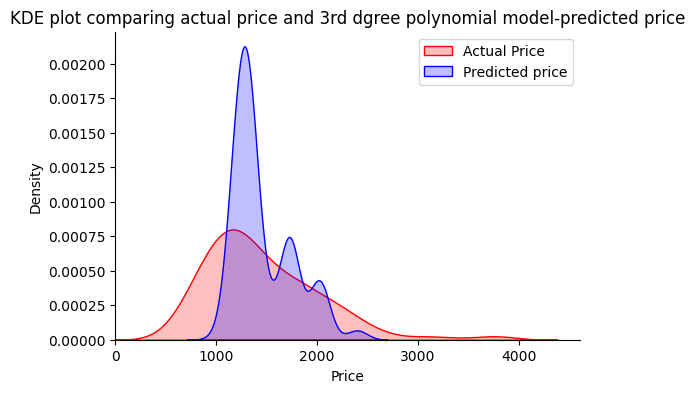

In [225]:
KDE_plot(Y3, Y_pred_3_3, "3rd")

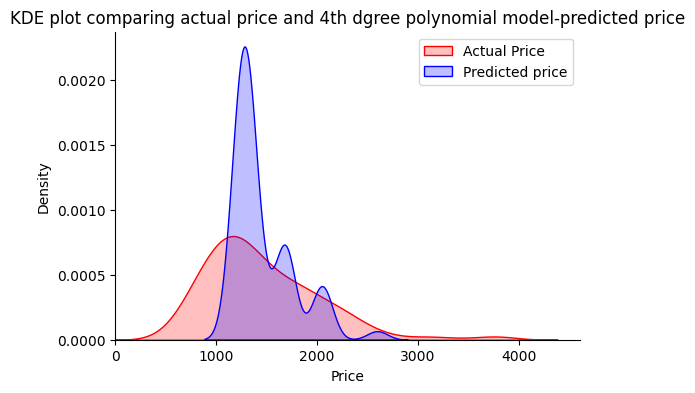

In [226]:
KDE_plot(Y3, Y_pred_3_4, "4th")

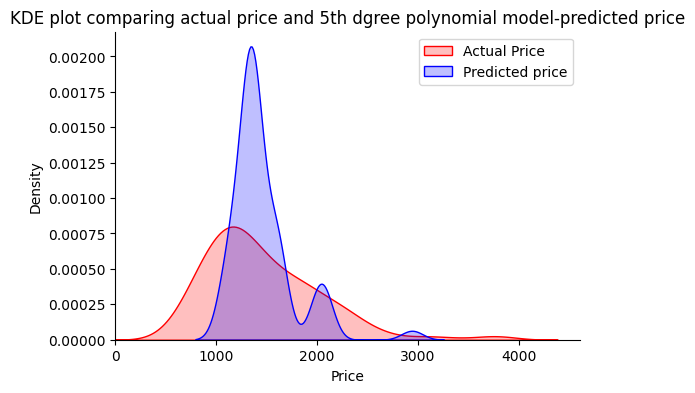

In [227]:
KDE_plot(Y3, Y_pred_3_5, "5th")

<h3>3. R2, MSE, and RMSE</h3>

In [228]:
def polynomial_metrics(Y_preds):
    R2_poly = []
    MSE_poly = []
    RMSE_poly = []
    for Y_pred in Y_preds:
        R2_poly_i = r2_score(Y3,Y_pred)
        R2_poly.append(R2_poly_i)
        MSE_poly_i = mean_squared_error(Y3,Y_pred)
        MSE_poly.append(MSE_poly_i)
        RMSE_poly_i = root_mean_squared_error(Y3, Y_pred)
        RMSE_poly.append(RMSE_poly_i)
    return {"R2": R2_poly,
            "MSE": MSE_poly,
            "RMSE": RMSE_poly}

In [231]:
Y_preds = [Y_pred_3_1, Y_pred_3_2, Y_pred_3_3, Y_pred_3_4, Y_pred_3_5]
metrics_df = polynomial_metrics(Y_preds)

In [235]:
polynomial_metrics_df = pd.DataFrame(metrics_df, index = ["Polynomial degree 1", "Polynomial degree 2", "Polynomial degree 3", "Polynomial degree 4", "Polynomial degree 5"])
polynomial_metrics_df

,R2,MSE,RMSE
Polynomial degree 1,0.134444,284583.440587,533.463626
Polynomial degree 2,0.242601,249022.665968,499.021709
Polynomial degree 3,0.266926,241024.863038,490.942831
Polynomial degree 4,0.278850,237104.557943,486.933833
Polynomial degree 5,0.303082,229137.295481,478.682876


<h2> D. Multivariate Polynomial Regression</h2>

<h3>1. Model Fit and Prediction </h3>

In [257]:
Input = [
    ("scale", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias = False)),
    ("model", LinearRegression())
]

pipe = Pipeline(Input)
#X2 = df[["CPU_frequency", "RAM_GB", "Storage_GB_SSD", "CPU_core", "OS", "GPU", "Category"]]
X2 = X2.astype(float)

pipe.fit(X2, Y2)
Ypipe= pipe.predict(X2)

In [258]:
model = pipe.named_steps["model"]
model.coef_

array([ 2.43786905e+02,  2.73662443e+02,  1.03058522e+16,  1.11447695e+02,
        1.52347705e+15,  2.52567732e+15,  1.26464319e+01,  1.54026474e+02,
       -3.18249868e+00,  6.59564235e+01, -9.77786957e+01,  7.54898602e+01,
        2.69196010e+01,  6.96109417e+01, -1.05449210e+02, -5.85106187e+01,
        1.88743112e+02, -3.67294978e+01,  1.37856150e+02,  2.08088878e+01,
        4.23613041e+15, -2.33287003e+02, -3.16764232e+15, -8.57478268e+15,
        5.69017292e+02,  9.95801736e+01,  3.77999606e+01, -6.00719551e+01,
       -6.35929383e+01, -1.57455255e+14, -2.63493561e+01, -7.57546800e+01,
        2.40558732e+01, -1.19211132e+02, -2.57983346e+00])

In [259]:
features = pipe.named_steps["polynomial"]
features_names = features.get_feature_names_out()
features_names

array(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x0^2', 'x0 x1', 'x0 x2',
       'x0 x3', 'x0 x4', 'x0 x5', 'x0 x6', 'x1^2', 'x1 x2', 'x1 x3',
       'x1 x4', 'x1 x5', 'x1 x6', 'x2^2', 'x2 x3', 'x2 x4', 'x2 x5',
       'x2 x6', 'x3^2', 'x3 x4', 'x3 x5', 'x3 x6', 'x4^2', 'x4 x5',
       'x4 x6', 'x5^2', 'x5 x6', 'x6^2'], dtype=object)

In [267]:
equation_parts = []
for coef, feature in zip(model.coef_, features_names):
    equation_parts.append(f"({coef:.2f})*{feature}")
    equation = "price" + " + ".join(equation_parts)
print(equation)

price(243.79)*x0 + (273.66)*x1 + (10305852181436144.00)*x2 + (111.45)*x3 + (1523477049855833.25)*x4 + (2525677323631231.00)*x5 + (12.65)*x6 + (154.03)*x0^2 + (-3.18)*x0 x1 + (65.96)*x0 x2 + (-97.78)*x0 x3 + (75.49)*x0 x4 + (26.92)*x0 x5 + (69.61)*x0 x6 + (-105.45)*x1^2 + (-58.51)*x1 x2 + (188.74)*x1 x3 + (-36.73)*x1 x4 + (137.86)*x1 x5 + (20.81)*x1 x6 + (4236130410209128.00)*x2^2 + (-233.29)*x2 x3 + (-3167642321771753.00)*x2 x4 + (-8574782678049597.00)*x2 x5 + (569.02)*x2 x6 + (99.58)*x3^2 + (37.80)*x3 x4 + (-60.07)*x3 x5 + (-63.59)*x3 x6 + (-157455255365612.38)*x4^2 + (-26.35)*x4 x5 + (-75.75)*x4 x6 + (24.06)*x5^2 + (-119.21)*x5 x6 + (-2.58)*x6^2


<h3>2. KDE plot </h3>

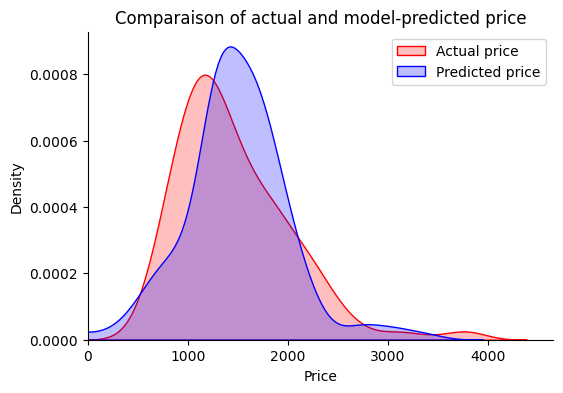

In [270]:
width = 6
height = 4
plt.figure(figsize=(width, height))
sns.kdeplot(Y2,color = "red", label = "Actual price", fill = True)
sns.kdeplot(Ypipe, color = "blue", label = "Predicted price", fill = True)
sns.despine()
plt.xlim(0,)
plt.legend()
plt.title("Comparaison of actual and model-predicted price")

plt.show()

<h3>3. R2, MSE, and RMSE </h3>

In [286]:
R2_multivariate_2nd = r2_score(Y2, Ypipe) #R2_multivariate_2nd= pipe.score(X2, Y2)
MSE_multivariate_2nd = mean_squared_error(Y2, Ypipe)
RMSE_multivariate_2nd = root_mean_squared_error(Y2, Ypipe)

print(f"For the second degree multivariate polynomial model, R2 = {R2_multivariate_2nd:.2f}, MSE = {MSE_multivariate_2nd:.2f}, and RMSE = {RMSE_multivariate_2nd:.2f}")


For the second degree multivariate polynomial model, R2 = 0.26, MSE = 244507.99, and RMSE = 494.48


<h1>IV. Conclusion</h1>

<p>For predicting price using polynomial regression on multiple features, increasing the polynomial degree improves model performance slightly. A second-degree multivariate polynomial model achieves R² ≈ 0.26 and RMSE ≈ 494, which is better than the degree 1 (linear) model but still much worse than the full multiple linear regression model (R² = 0.51, RMSE = 402) using all features. Higher polynomial degrees (3–5) continue to reduce MSE and RMSE slightly and increase R² modestly, indicating some improvement, but the gains are marginal compared to the multiple linear regression model. This suggests that while polynomial terms capture some nonlinear relationships, the multiple linear regression model with all features provides the most accurate and stable prediction of price.</p>